**Parallel Workflow**

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv


In [2]:
load_dotenv()

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.1,
    max_retries=2,
)

In [17]:
# 1. Define the State
class CricketState(TypedDict):
    # Inputs
    runs: int
    balls: int
    fours: int
    sixes: int
    # Parallel Outputs
    strike_rate: str
    boundary_percent: str
    balls_per_boundary: str
    # Final Summary
    final_report: str

In [11]:
# 2. Define the Nodes - THE CORRECTED WAY
def calc_strike_rate(state: CricketState):
    # Calculate but DON'T modify state['strike_rate'] directly
    sr = (state['runs'] / state['balls']) * 100 
    
    # ONLY return the key this node is responsible for
    return {"strike_rate": sr} 

def calc_frequency(state: CricketState):
    total_boundaries = state['fours'] + state['sixes']
    bp = state['balls'] / total_boundaries if total_boundaries > 0 else 0
    
    return {"balls_per_boundary": bp}

def calc_boundary_percent(state: CricketState):
    boundary_runs = (state['fours'] * 4) + (state['sixes'] * 6)
    boundary_per = (boundary_runs / state['runs']) * 100
    
    return {"boundary_percent": boundary_per}

def generate_report(state: CricketState):
    # This node is the "Join" point, it sees the merged state
    report = (
        f"FINAL PERFORMANCE REPORT:\n"
        f"- Strike Rate: {state['strike_rate']:.2f}\n"
        f"- Boundary %: {state['boundary_percent']:.2f}%\n"
        f"- Balls per Boundary: {state['balls_per_boundary']:.2f}"
    )
    return {"final_report": report}

In [ ]:
# 3. Build the Graph
builder = StateGraph(CricketState)

builder.add_node("calc_strike_rate", calc_strike_rate)
builder.add_node("calc_boundary_percent", calc_boundary_percent)
builder.add_node("calc_frequency", calc_frequency)
builder.add_node("generate_report", generate_report)

# We send the START to all three calculation nodes simultaneously
builder.add_edge(START, "calc_strike_rate")
builder.add_edge(START, "calc_boundary_percent")
builder.add_edge(START, "calc_frequency")

# We point all three calculation nodes to the final report node
builder.add_edge("calc_strike_rate", "generate_report")
builder.add_edge("calc_boundary_percent", "generate_report")
builder.add_edge("calc_frequency", "generate_report")

builder.add_edge("generate_report", END)

# 4. Compile and Execute
graph = builder.compile()

In [14]:
stats = {
    "runs": 82,
    "balls": 53,
    "fours": 6,
    "sixes": 4
}

result = graph.invoke(stats)

In [15]:
print(result['final_report'])

FINAL PERFORMANCE REPORT:
- Strike Rate: 154.72
- Boundary %: 58.54%
- Balls per Boundary: 5.30


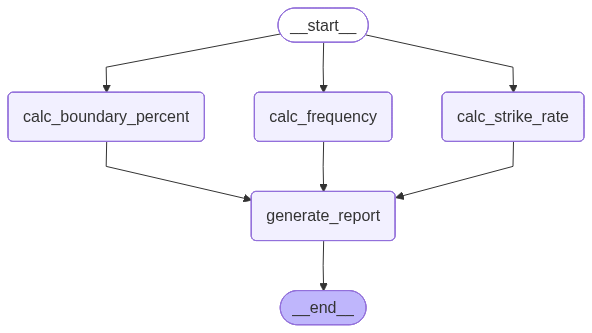

In [16]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())